In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt

In [ ]:
import kagglehub
import os

path = kagglehub.dataset_download("atharvaingle/crop-recommendation-dataset")

file_path = os.path.join(path, "Crop_recommendation.csv")
df = pd.read_csv(file_path)

df.head()

100%|██████████| 63.7k/63.7k [00:00<00:00, 34.9MB/s]

Extracting files...


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [ ]:
print(df.columns)
print(df.shape)
df.info()

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')
(2200, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [ ]:
X = df.drop("label", axis=1)
y = df["label"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [ ]:
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9954545454545455

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      0.95      0.97        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.95      1.00      0.98        20
           9       1.00      1.00      1.00        20
          10       1.00      1.00      1.00        20
          11       0.95      1.00      0.98        20
          12       1.00      1.00      1.00        20
          13       1.00      1.00      1.00        20
          14       1.00      1.00      1.00        20
          15       1.00      1.00      1.00        20
          16       1.00    

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 19  0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  

In [ ]:
print("Crop Classes:", le.classes_)

Crop Classes: ['apple' 'banana' 'blackgram' 'chickpea' 'coconut' 'coffee' 'cotton'
 'grapes' 'jute' 'kidneybeans' 'lentil' 'maize' 'mango' 'mothbeans'
 'mungbean' 'muskmelon' 'orange' 'papaya' 'pigeonpeas' 'pomegranate'
 'rice' 'watermelon']


In [ ]:
def predict_crop(N, P, K, temperature, humidity, ph, rainfall):
    input_df = pd.DataFrame([{
        'N': N,
        'P': P,
        'K': K,
        'temperature': temperature,
        'humidity': humidity,
        'ph': ph,
        'rainfall': rainfall
    }])

    prediction = model.predict(input_df)
    crop_name = le.inverse_transform(prediction)
    return crop_name[0]

In [ ]:
def predict_top3(N, P, K, temperature, humidity, ph, rainfall):
    input_df = pd.DataFrame([{
        'N': N,
        'P': P,
        'K': K,
        'temperature': temperature,
        'humidity': humidity,
        'ph': ph,
        'rainfall': rainfall
    }])

    probs = model.predict_proba(input_df)
    top3 = np.argsort(probs[0])[-3:][::-1]

    crops = le.inverse_transform(top3)
    confidences = probs[0][top3]

    for crop, conf in zip(crops, confidences):
        print(f"{crop} → {conf:.2f}")

In [ ]:
print("Recommended Crop:", predict_crop(90, 42, 43, 20, 82, 6.5, 200))
predict_top3(90, 42, 43, 20, 82, 6.5, 200)

Recommended Crop: rice
rice → 0.92
jute → 0.09
pomegranate → 0.00


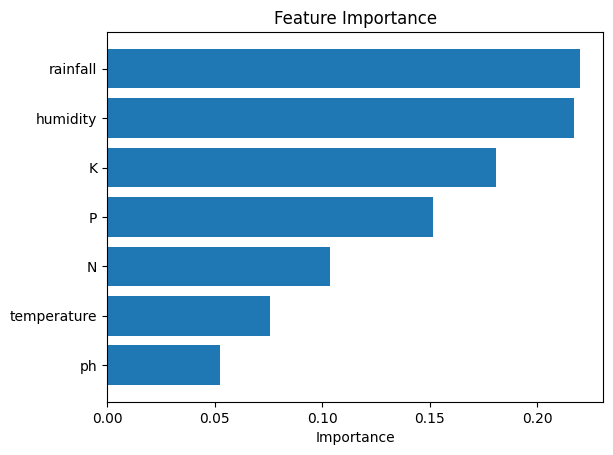

In [ ]:
importances = model.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure()
plt.barh(feat_df['Feature'], feat_df['Importance'])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()

In [14]:
print("Model Accuracy: {:.2f}%".format(accuracy_score(y_test, y_pred)*100))

Model Accuracy: 99.55%


In [16]:
print("Recommended Crop:", predict_crop(60, 40, 30, 25, 60, 6.0, 100))
predict_top3(60, 40, 30, 25, 60, 6.0, 100)

Recommended Crop: maize
maize → 0.42
coffee → 0.41
mango → 0.08


In [17]:
print("Recommended Crop:", predict_crop(20, 10, 10, 30, 70, 5.5, 150))
predict_top3(20, 10, 10, 30, 70, 5.5, 150)

Recommended Crop: orange
orange → 0.28
pigeonpeas → 0.23
mango → 0.17


In [18]:
print("Recommended Crop:", predict_crop(100, 50, 50, 28, 85, 6.5, 250))
predict_top3(100, 50, 50, 28, 85, 6.5, 250)

Recommended Crop: rice
rice → 0.34
papaya → 0.26
banana → 0.18
